# Evaluate Gamma - Hadron Discrimination Performance

This code finds the best threshold probability and evaluates proton-residual-fraction (or proton efficiency) at 80% gamma efficiency. It plots probability distirbutions at event level for gammas and protons and makes muon-counting plots.

- Please label savefiles descriptively and uniquely in the pictures/

In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase
from matplotlib.legend_handler import HandlerLine2D
import matplotlib.transforms as mtransforms

from py_code import config_loader 
from py_code import gamma_hadron_separation as gh
from matplotlib.lines import Line2D
from matplotlib import colors

In [2]:
conf = config_loader.load_config("config.yaml")
DAT_path_protons = conf["DAT_path_protons"]
DAT_path_gammas = conf["DAT_path_gammas"]

TRAIN_DAT_MIN = conf["TRAIN_DAT_MIN"]
TRAIN_DAT_MAX = conf["TRAIN_DAT_MAX"]

TEST_PROTONS_DAT_MIN = conf["TEST_PROTONS_DAT_MIN"]
TEST_PROTONS_DAT_MAX = conf["TEST_PROTONS_DAT_MAX"]

TEST_GAMMAS_DAT_MIN = conf["TEST_GAMMAS_DAT_MIN"]
TEST_GAMMAS_DAT_MAX = conf["TEST_GAMMAS_DAT_MAX"]

traces_dir = conf["traces_dir"]
feats_dir =  conf["feats_dir"]
output_dir = conf["output_dir"]
models_dir = conf["models_dir"]
results_dir = conf["results_dir"]
pictures_dir = conf["pictures_dir"]

params_dir = conf["params_dir"]
cut_dir = conf["cut_dir"]
ADC_dir = conf["ADC_dir"]
array_dir = conf["array_dir"]

features_cut_dir = conf["features_cut_dir"]
training_selection_dir = conf["training_selection_dir"]
testing_selection_dir = conf["testing_selection_dir"]

tank_type = conf["tank_type"]
FF = conf["FF"]
time_window = conf["time_window"]
min_energy_reco = conf["min_energy_reco"]
max_energy_reco = conf["max_energy_reco"]
min_theta = conf["min_theta"]
max_theta = conf["max_theta"]
intended_cut_on_pes = conf["intended_cut_on_pes"]
mpmt_or_8inches = conf["mpmt_or_8inches"]
ADC_MHz = conf["ADC_MHz"]

train_min_st_dist = conf["train_min_st_dist"]
train_max_st_dist = conf["train_max_st_dist"]
train_pe_min = conf["train_pe_min"]

test_min_st_dist = conf["test_min_st_dist"]
test_max_st_dist = conf["test_max_st_dist"]
test_pe_min = conf["test_pe_min"]

gamma_hadron_discrimination_val_split = conf["gamma_hadron_discrimination_val_split"]
event_stations_multiplicity = conf["event_stations_multiplicity"]

In [3]:
PROJECT_DIR = Path.cwd().parent

In [4]:
# Specify txt files with probabilities
PROTONS_txt_dir = Path(f"{PROJECT_DIR}/{output_dir}/{array_dir}/test_protons/{params_dir}/{features_cut_dir}/{testing_selection_dir}/")
GAMMAS_txt_dir = Path(f"{PROJECT_DIR}/{output_dir}/{array_dir}/test_gammas/{params_dir}/{features_cut_dir}/{testing_selection_dir}/")

pictures_save_dir = Path(f"{PROJECT_DIR}/{pictures_dir}/{array_dir}/{params_dir}/{training_selection_dir}/{testing_selection_dir}/") 
pictures_save_dir.mkdir(parents=True, exist_ok = True)

results_save_dir = Path(f"{PROJECT_DIR}/{results_dir}/{array_dir}/{params_dir}/{training_selection_dir}/{testing_selection_dir}/") 
results_save_dir.mkdir(parents = True, exist_ok = True)

In [5]:
result = gh.get_primary_results(proton_txt_dir = PROTONS_txt_dir, gamma_txt_dir = GAMMAS_txt_dir, 
                                gamma_hadron_discrimination_val_split = gamma_hadron_discrimination_val_split)

print("Number of Protons = ", result.number_of_protons)

print("Number of Gammas = ", result.number_of_gammas)

protons_validation = result.protons_info_val
gammas_validation = result.gammas_info_val

protons_testing = result.protons_info_test
gammas_testing = result.gammas_info_test

Number of Protons =  4153
Number of Gammas =  2809


In [6]:
multiplicity = event_stations_multiplicity

triggered_validation = gh.station_multiplicity_trigger(protons = protons_validation, gammas = gammas_validation, multiplicity = multiplicity)
triggered_testing = gh.station_multiplicity_trigger(protons = protons_testing, gammas = gammas_testing, multiplicity = multiplicity)

protons_validation = triggered_validation.triggered_protons
gammas_validation = triggered_validation.triggered_gammas

protons_testing = triggered_testing.triggered_protons
gammas_testing = triggered_testing.triggered_gammas

print("Multiplicity Trigger = ", multiplicity)
print("Validation protons after station multiplicity cut = ", len(protons_validation))
print("Validation gammas after station multiplicity cut = ", len(gammas_validation))
print("Test protons after station multiplicity cut = ", len(protons_testing))
print("Test gammas after station multiplicity cut = ", len(gammas_testing))

Multiplicity Trigger =  1
Validation protons after station multiplicity cut =  2076
Validation gammas after station multiplicity cut =  1404
Test protons after station multiplicity cut =  2077
Test gammas after station multiplicity cut =  1405


In [7]:
best_threshold_val, minimum_fpr_on_validation = gh.get_best_threshold_on_val(protons_info_val = protons_validation, 
                                                                             gammas_info_val = gammas_validation)

Gamma efficiency target = 0.8
Min FPR on Validation = 1.45e-02
Best Threshold on Validation = 0.789790


In [8]:
gamma_percentile = 80

summed_probabilities = gh.get_summed_probabilities(best_threshold_val = best_threshold_val, protons_validation = protons_validation, protons_testing = protons_testing, gammas_validation = gammas_validation, gammas_testing = gammas_testing)

protons_val = np.asarray(summed_probabilities.sum_probs_protons_val, dtype = float)
protons_test = np.asarray(summed_probabilities.sum_probs_protons_test, dtype = float)
gammas_val = np.asarray(summed_probabilities.sum_probs_gammas_val, dtype = float)
gammas_test = np.asarray(summed_probabilities.sum_probs_gammas_test, dtype = float)

threshold_val = np.percentile(gammas_val, gamma_percentile)
threshold_test= np.percentile(gammas_test, gamma_percentile)

protons_in_gamma_region = protons_test[(protons_test >= 0) & (protons_test <= threshold_val)]
fpr_test = len(protons_in_gamma_region)/len(protons_test)

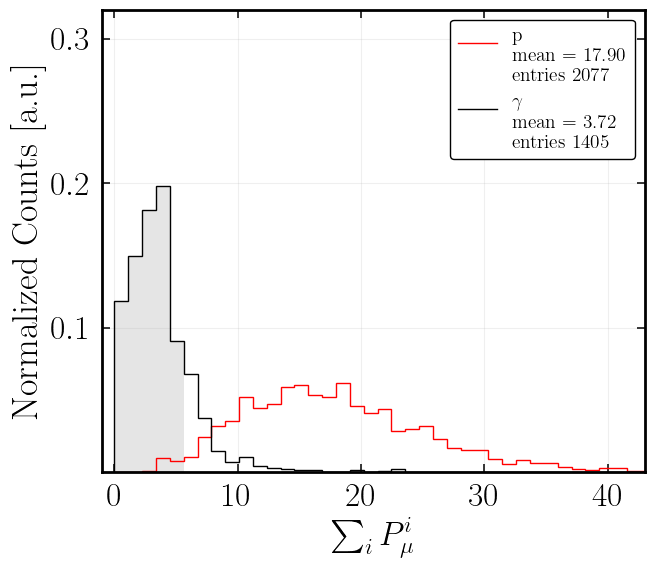

Mean Protons =  17.8961334628843
Mean Gammas =  3.724119996940142
Gamma 80% [val] threshold =  5.13083555698
Number of protons in 80% test gamma region =  31
Fraction of protons kept in the test set =  0.014925373134328358


In [9]:
bins = np.linspace(0, 100, 90)

gammas_hist, edges = np.histogram(gammas_test, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
mask = edges[:-1] < threshold_val

plt.figure(figsize=(7,6))

plt.hist(protons_test, color="red", histtype="step", label="p",
         density=True, bins=bins)

counts, edges, _ = plt.hist(gammas_test, color="black", histtype="step", label=r"$\gamma$", density=True, bins=bins, linewidth = 1)

centers = (edges[:-1] + edges[1:]) / 2

plt.bar(centers[mask], counts[mask], width=np.diff(edges)[mask], align="center", alpha = 0.1, color="black", edgecolor="none")

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

handles = [
    Line2D([0], [0], color="red", linewidth=1),
    Line2D([0], [0], color="black", linewidth=1)
]

labels = [
    r"p" + "\n" f"mean = {np.mean(protons_test):.2f}" + "\n" f"entries {len(protons_test)}",
    r" $\gamma$" + "\n" f"mean = {np.mean(gammas_test):.2f}" + "\n" f"entries {len(gammas_test)}"
]

plt.xticks([0, 10, 20, 30, 40])
plt.yticks([0, 0.1, 0.2, 0.3])

plt.tick_params(axis="both", which="major", labelsize=24, length=6)
plt.minorticks_off()
plt.xlabel(r"$\sum_{i} P_{\mu}^{i}$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)
plt.grid(True, alpha=0.2)

plt.xlim(-1,43)
plt.ylim(1e-4, 3.2e-1)

plt.legend(handles=handles,labels=labels,handler_map={Line2D: gh.OffsetLineHandler(y_offset=13)},edgecolor="black",facecolor="white",framealpha=1.0,fontsize=14)

plt.savefig(pictures_save_dir / "sum_probabilities_gamma_proton_distribution.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "sum_probabilities_gamma_proton_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

print("Mean Protons = ", np.mean(protons_test))
print("Mean Gammas = ", np.mean(gammas_test))
print("Gamma 80% [val] threshold = ", threshold_val)
print("Number of protons in 80% test gamma region = ", len(protons_in_gamma_region))
print("Fraction of protons kept in the test set = ", fpr_test)

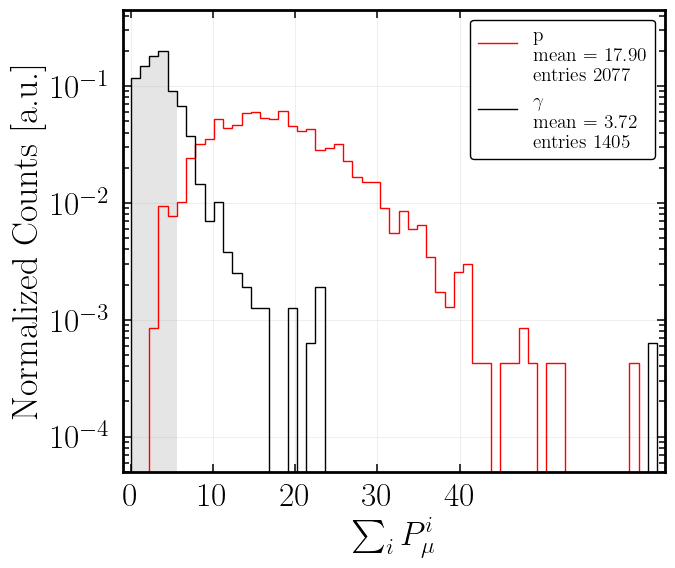

In [10]:
bins = np.linspace(0, 100, 90)
gammas_hist, edges = np.histogram(gammas_test, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
mask = edges[:-1] < threshold_val

plt.figure(figsize=(7,6))

plt.hist(protons_test, color="red", histtype="step", label="p",
         density=True, bins=bins)

counts, edges, _ = plt.hist(gammas_test, color="black", histtype="step", label=r"$\gamma$", density=True, bins=bins, linewidth = 1)

centers = (edges[:-1] + edges[1:]) / 2

plt.bar(centers[mask], counts[mask], width=np.diff(edges)[mask], align="center", alpha = 0.1, color="black", edgecolor="none")

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

handles = [
    Line2D([0], [0], color="red", linewidth=1),
    Line2D([0], [0], color="black", linewidth=1)]

labels = [
    r"p" + "\n" f"mean = {np.mean(protons_test):.2f}" + "\n" f"entries {len(protons_test)}",
    r" $\gamma$" + "\n" f"mean = {np.mean(gammas_test):.2f}" + "\n" f"entries {len(gammas_test)}"]

plt.xticks([0, 10, 20, 30, 40])
plt.yticks([0, 0.1, 0.2, 0.3])

plt.tick_params(axis="both", which="major", labelsize=24, length=6)
plt.minorticks_off()
plt.xlabel(r"$\sum_{i} P_{\mu}^{i}$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)
plt.grid(True, alpha=0.2)

plt.yscale("log")

plt.xlim(-1,65)
plt.ylim(0.5e-4, 4.5e-1)

plt.legend(handles=handles,labels=labels,handler_map={Line2D: gh.OffsetLineHandler(y_offset=13)},edgecolor="black",facecolor="white",framealpha=1.0,fontsize=14)

plt.savefig(pictures_save_dir / "log_gamma_proton_distribution.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "log_gamma_proton_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

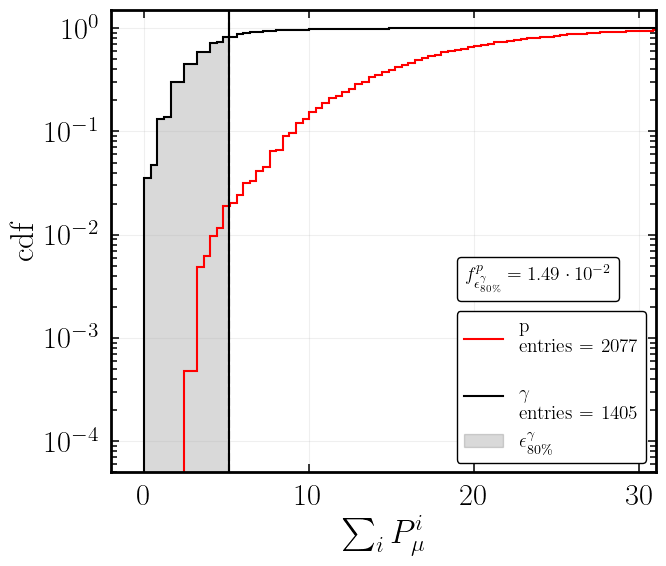

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

counts_g, bins_g, _ = ax.hist(gammas_test, bins=150, histtype="step", color="black", linewidth=1.5, cumulative=1, density=True, range=(0,60))
ax.hist(protons_test, bins=150, histtype="step", color="red", linewidth=1.5, cumulative=1, density=True, range=(0,60))

centers = 0.5 * (bins_g[:-1] + bins_g[1:])
mask = centers <= threshold_val

ax.bar(centers[mask], counts_g[mask], width=np.diff(bins_g)[mask], align="center", color="black", alpha=0.15, edgecolor="none")
ax.axvline(threshold_test, color="black", linestyle="--", linewidth=1.5, label = "Test 80%")
ax.axvline(threshold_val, color="black", linestyle="-", linewidth=1.5, label = "Validation 80%")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=22, length=6)
ax.minorticks_off()

ax.set_xlabel(r"$\sum_{i} P_{\mu}^{i}$", fontsize=24)
ax.set_ylabel("cdf", fontsize=24)

ax.set_yscale("log")
ax.set_ylim(0.5e-4, 1.5)
ax.set_xlim(-2,31)

ax.grid(True, alpha=0.2)

handles = [
    plt.Line2D([0], [0], color="red", linewidth=1.5),
    plt.Line2D([0], [0], color="black", linewidth=1.5),
    plt.Rectangle((0, 0), 1, 1, color="black", alpha=0.15)
]

labels = [
    f"p\nentries = {len(protons_test)} \n",
    f"$\\gamma$\nentries = {len(gammas_test)}",
    "$\epsilon^{\gamma}_{80 \%}$"
]

fpr = np.sum(protons_test <= threshold_val) / len(protons_test)
mantissa, exponent = f"{fpr:.2e}".split("e")

legend_text = ax.legend([plt.Line2D([], [], linestyle="none")],
                        [rf"$f^p_{{\epsilon^{{\gamma}}_{{80\%}}}} = {float(mantissa):.2f}\cdot10^{{{int(exponent)}}}$"],
                        fontsize=14,
                        edgecolor="black",
                        facecolor="white",
                        framealpha=1.0,
                        loc="lower right",
                        bbox_to_anchor=(0.95, 0.35),
                        handlelength=0,
                        handletextpad=0)

ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0, loc="lower right", handler_map={Line2D: gh.OffsetLineHandler(y_offset=8)})


ax.add_artist(legend_text)

plt.tight_layout()

plt.savefig(pictures_save_dir / "cumulative_gamma_proton_distribution.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "cumulative_gamma_proton_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

In [12]:
best_threshold_val_mean, minimum_fpr_on_validation_mean = gh.get_best_threshold_on_val_mean(protons_info_val = protons_validation, 
                                                                                             gammas_info_val = gammas_validation)

gamma_percentile_mean = 80

mean_summed_probabilities = gh.get_mean_summed_probabilities(best_threshold_val = best_threshold_val_mean, protons_validation = protons_validation, protons_testing = protons_testing, gammas_validation = gammas_validation, gammas_testing = gammas_testing)

mean_protons_val = np.asarray(mean_summed_probabilities.mean_sum_probs_protons_val, dtype = float)
mean_protons_test = np.asarray(mean_summed_probabilities.mean_sum_probs_protons_test, dtype = float)
mean_gammas_val = np.asarray(mean_summed_probabilities.mean_sum_probs_gammas_val, dtype = float)
mean_gammas_test = np.asarray(mean_summed_probabilities.mean_sum_probs_gammas_test, dtype = float)

mean_threshold_val = np.percentile(mean_gammas_val, gamma_percentile_mean)
mean_threshold_test = np.percentile(mean_gammas_test, gamma_percentile_mean)

mean_protons_in_gamma_region = mean_protons_test[(mean_protons_test >= 0) & (mean_protons_test <= mean_threshold_val)]
mean_fpr_test = len(mean_protons_in_gamma_region)/len(mean_protons_test)

Gamma efficiency target = 0.8
Min FPR on Validation = 4.34e-03
Best Threshold on Validation = 0.681682
Mean Number of fired tanks for Protons:  287.62060664419835
Mean Number of fired tanks for Gammas:  282.0384341637011


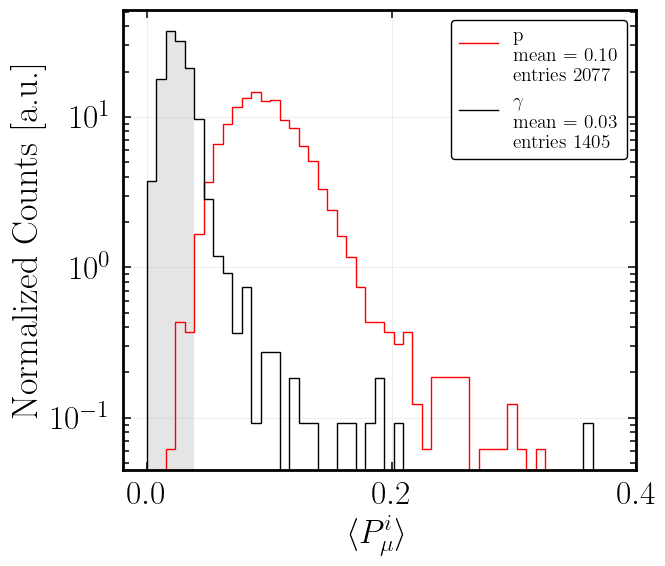

In [13]:
mean_bins = np.linspace(0, 1, 130)

plt.figure(figsize=(7,6))

plt.hist(mean_protons_test, color="red", histtype="step", label="p",
         density=True, bins=mean_bins)

mean_counts, mean_edges, _ = plt.hist(mean_gammas_test, color="black", histtype="step", label=r"$\gamma$", density=True, bins=mean_bins, linewidth = 1)

mean_centers = (mean_edges[:-1] + mean_edges[1:]) / 2
mean_mask = mean_edges[:-1] < mean_threshold_val

plt.bar(mean_centers[mean_mask], mean_counts[mean_mask], width=np.diff(mean_edges)[mean_mask], align="center", alpha = 0.1, color="black", edgecolor="none")

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

handles = [
    Line2D([0], [0], color="red", linewidth=1),
    Line2D([0], [0], color="black", linewidth=1)]

labels = [
    r"p" + "\n" f"mean = {np.mean(mean_protons_test):.2f}" + "\n" f"entries {len(mean_protons_test)}",
    r" $\gamma$" + "\n" f"mean = {np.mean(mean_gammas_test):.2f}" + "\n" f"entries {len(mean_gammas_test)}"]

plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])

plt.tick_params(axis="both", which="major", labelsize=24, length=6)
plt.minorticks_off()
plt.xlabel(r"$\langle P_{\mu}^{i}\rangle$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)
plt.grid(True, alpha=0.2)

plt.yscale("log")

plt.xlim(-0.02,0.4)

plt.legend(handles=handles,labels=labels,handler_map={Line2D: gh.OffsetLineHandler(y_offset=13)},edgecolor="black",facecolor="white",framealpha=1.0,fontsize=14)

plt.tight_layout()

plt.savefig(pictures_save_dir / "mean_log_gamma_proton_distribution.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "mean_log_gamma_proton_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

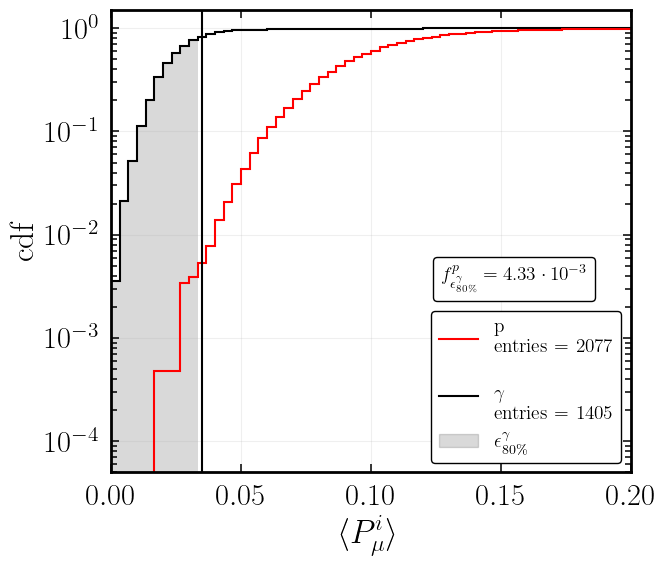

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

mean_counts_g, mean_bins_g, _ = ax.hist(mean_gammas_test, bins=300, histtype="step", color="black", linewidth=1.5, cumulative=1, density=True, range=(0,1))
ax.hist(mean_protons_test, bins=300, histtype="step", color="red", linewidth=1.5, cumulative=1, density=True, range=(0,1))

mean_centers = 0.5 * (mean_bins_g[:-1] + mean_bins_g[1:])
mean_mask = mean_centers <= mean_threshold_val

ax.bar(mean_centers[mean_mask], mean_counts_g[mean_mask], width=np.diff(mean_bins_g)[mean_mask], align="center", color="black", alpha=0.15, edgecolor="none")
#ax.axvline(mean_threshold_test, color="black", linestyle="--", linewidth=1.5, label = f"Test {gamma_percentile_mean}%")
ax.axvline(mean_threshold_val, color="black", linestyle="-", linewidth=1.5, label = f"Validation {gamma_percentile_mean}%")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=22, length=6)
ax.minorticks_off()

ax.set_xlabel(r"$\langle P_{\mu}^{i}\rangle$", fontsize=24)
ax.set_ylabel("cdf", fontsize=24)

ax.set_yscale("log")
ax.set_ylim(0.5e-4, 1.5)
ax.set_xlim(0,0.2)

ax.grid(True, alpha=0.2)

handles = [
    plt.Line2D([0], [0], color="red", linewidth=1.5),
    plt.Line2D([0], [0], color="black", linewidth=1.5),
    plt.Rectangle((0, 0), 1, 1, color="black", alpha=0.15)
]

labels = [
    f"p\nentries = {len(mean_protons_test)} \n",
    f"$\\gamma$\nentries = {len(mean_gammas_test)}",
    rf"$\epsilon^{{\gamma}}_{{{gamma_percentile_mean}\%}}$"
]

mean_fpr_test = np.sum(mean_protons_test <= mean_threshold_val) / len(mean_protons_test)
mean_mantissa, mean_exponent = f"{mean_fpr_test:.2e}".split("e")

legend_text = ax.legend([plt.Line2D([], [], linestyle="none")],
                        [rf"$f^p_{{\epsilon^{{\gamma}}_{{{gamma_percentile_mean}\%}}}} = {float(mean_mantissa):.2f}\cdot10^{{{int(mean_exponent)}}}$"],
                        fontsize=14,
                        edgecolor="black",
                        facecolor="white",
                        framealpha=1.0,
                        loc="lower right",
                        bbox_to_anchor=(0.95, 0.35),
                        handlelength=0,
                        handletextpad=0)

ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0, loc="lower right", handler_map={plt.Line2D: gh.OffsetLineHandler(y_offset=8)})

ax.add_artist(legend_text)

plt.tight_layout()

plt.savefig(pictures_save_dir / "mean_cumulative_gamma_proton_distribution.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "mean_cumulative_gamma_proton_distribution.png", dpi=600, bbox_inches="tight")

plt.show()

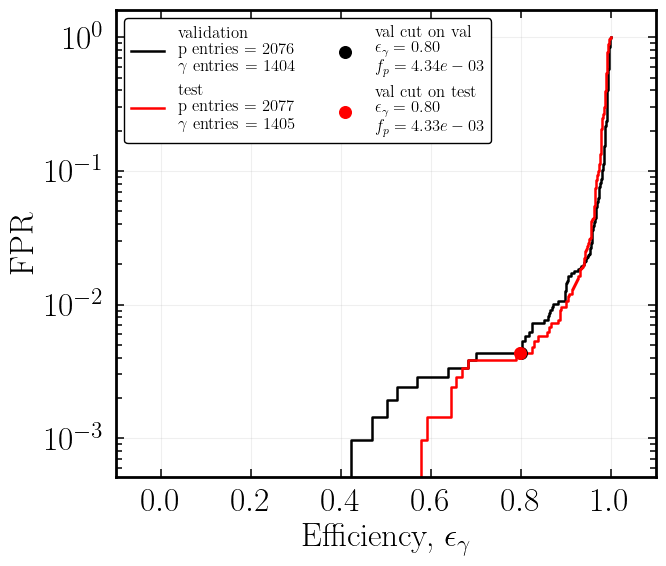

In [15]:
from sklearn.metrics import roc_curve

mean_y_val = np.concatenate([np.zeros(len(mean_protons_val)), np.ones(len(mean_gammas_val))])
mean_scores_val = np.concatenate([mean_protons_val, mean_gammas_val])

mean_y_test = np.concatenate([np.zeros(len(mean_protons_test)), np.ones(len(mean_gammas_test))])
mean_scores_test = np.concatenate([mean_protons_test, mean_gammas_test])

mean_fpr_val, mean_tpr_val, mean_thr_val = roc_curve(mean_y_val, -mean_scores_val)
mean_fpr_test, mean_tpr_test, mean_thr_test = roc_curve(mean_y_test, -mean_scores_test)

mean_threshold_val = np.percentile(mean_gammas_val, gamma_percentile_mean)

mean_tpr_val_80 = np.mean(mean_gammas_val <= mean_threshold_val)
mean_fpr_val_80 = np.mean(mean_protons_val <= mean_threshold_val)

mean_tpr_test_80 = np.mean(mean_gammas_test <= mean_threshold_val)
mean_fpr_test_80 = np.mean(mean_protons_test <= mean_threshold_val)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(mean_tpr_val, mean_fpr_val, color="black", linewidth=1.8, linestyle="-",
        label=(f"validation\n"
        f"p entries = {len(mean_protons_val)}\n"
        f"$\\gamma$ entries = {len(mean_gammas_val)}"))

ax.plot(mean_tpr_test, mean_fpr_test, color="red", linewidth=1.8, linestyle="-",
    label=(f"test\n"
        f"p entries = {len(mean_protons_test)}\n"
        f"$\\gamma$ entries = {len(mean_gammas_test)}"))

ax.scatter(mean_tpr_val_80, mean_fpr_val_80, color="black", marker="o", s=70, zorder=5,
    label=(
        rf"val cut on val"
        "\n"
        rf"$\epsilon_\gamma={mean_tpr_val_80:.2f}$"
        "\n"
        rf"$f_p={mean_fpr_val_80:.2e}$"))

ax.scatter(mean_tpr_test_80, mean_fpr_test_80, color="red", marker="o", s=70, zorder=5,
    label=(
        rf"val cut on test"
        "\n"
        rf"$\epsilon_\gamma={mean_tpr_test_80:.2f}$"
        "\n"
        rf"$f_p={mean_fpr_test_80:.2e}$"))

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=6)
ax.minorticks_off()

ax.set_xlabel(r"Efficiency, $\epsilon_{\gamma}$", fontsize=24)
ax.set_ylabel("FPR", fontsize=24)

ax.set_yscale("log")
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0.51e-3, 1.6)

ax.grid(True, alpha=0.2)
plt.xticks([0, 0.20, 0.40, 0.60, 0.80, 1])

ax.legend(fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", ncols = 2)

plt.tight_layout()

plt.savefig(pictures_save_dir / "mean_val_vs_test_peff_vs_geff_gamma_proton.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "mean_val_vs_test_peff_vs_geff_gamma_proton.png", dpi=600, bbox_inches="tight")

plt.show()

In [16]:
threshold_val_80 = np.percentile(gammas_val, 80)

tpr_val_80 = np.mean(gammas_val <= threshold_val)
fpr_val_80 = np.mean(protons_val <= threshold_val)

tpr_test_80 = np.mean(gammas_test <= threshold_val)
fpr_test_80 = np.mean(protons_test <= threshold_val)

print(f"Validation threshold = {threshold_val_80:.2f}")

print(f"Validation gamma fraction = {tpr_val_80:.2f}")
print(f"Validation proton fraction = {fpr_val_80:.3e}")

print(f"Test gamma fraction = {tpr_test_80:.2f}")
print(f"Test proton fraction = {fpr_test_80:.3e}")

Validation threshold = 5.13
Validation gamma fraction = 0.80
Validation proton fraction = 1.445e-02
Test gamma fraction = 0.79
Test proton fraction = 1.493e-02


In [17]:
roc_test = gh.get_ROC(gammas=gammas_test, protons=protons_test, n_points=1000)
roc_val = gh.get_ROC(gammas=gammas_val, protons=protons_val, n_points=1000)

tpr_test = roc_test.tpr
fpr_test = roc_test.fpr
thr_test = roc_test.thresholds

tpr_val = roc_val.tpr
fpr_val = roc_val.fpr
thr_val = roc_val.thresholds

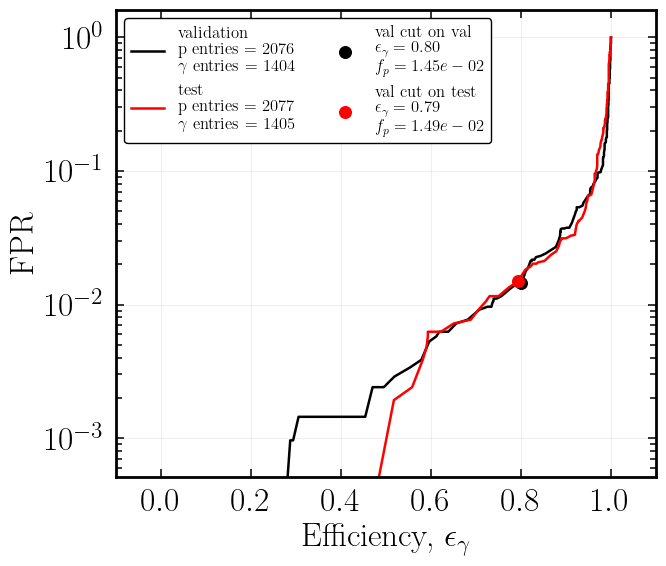

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(tpr_val, fpr_val, color="black", linewidth=1.8, linestyle="-", 
        label=(f"validation\n"
        f"p entries = {len(protons_val)}\n"
        f"$\\gamma$ entries = {len(gammas_val)}"))

ax.plot(tpr_test, fpr_test, color="red", linewidth=1.8, linestyle="-",
    label=(f"test\n"
        f"p entries = {len(protons_test)}\n"
        f"$\\gamma$ entries = {len(gammas_test)}"))

ax.scatter(tpr_val_80, fpr_val_80, color="black", marker="o", s=70, zorder=5,
    label=(
        rf"val cut on val"
        "\n"
        rf"$\epsilon_\gamma={tpr_val_80:.2f}$"
        "\n"
        rf"$f_p={fpr_val_80:.2e}$"))

ax.scatter(tpr_test_80, fpr_test_80, color="red", marker="o", s=70, zorder=5,
    label=(
        rf"val cut on test"
        "\n"
        rf"$\epsilon_\gamma={tpr_test_80:.2f}$"
        "\n"
        rf"$f_p={fpr_test_80:.2e}$"))

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=6)
ax.minorticks_off()

ax.set_xlabel(r"Efficiency, $\epsilon_{\gamma}$", fontsize=24)
ax.set_ylabel("FPR", fontsize=24)

ax.set_yscale("log")
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0.51e-3, 1.6)

ax.grid(True, alpha=0.2)
plt.xticks([0, 0.20, 0.40, 0.60, 0.80, 1])

ax.legend(fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", ncols = 2)

plt.tight_layout()

plt.savefig(pictures_save_dir / "val_vs_test_peff_vs_geff_gamma_proton.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "val_vs_test_peff_vs_geff_gamma_proton.png", dpi=600, bbox_inches="tight")

plt.show()

In [19]:
gh.save_ROC_results(
    results_save_dir=results_save_dir,
    validation_split=gamma_hadron_discrimination_val_split,
    protons_val=protons_val,
    gammas_val=gammas_val,
    protons_test=protons_test,
    gammas_test=gammas_test,
    threshold_val=threshold_val,
    gamma_fraction_val=tpr_val_80,
    proton_fraction_val=fpr_val_80,
    gamma_fraction_test=tpr_test_80,
    proton_fraction_test=fpr_test_80,
    tpr_val=tpr_val,
    fpr_val=fpr_val,
    thr_val=thr_val,
    tpr_test=tpr_test,
    fpr_test=fpr_test,
    thr_test=thr_test)

0

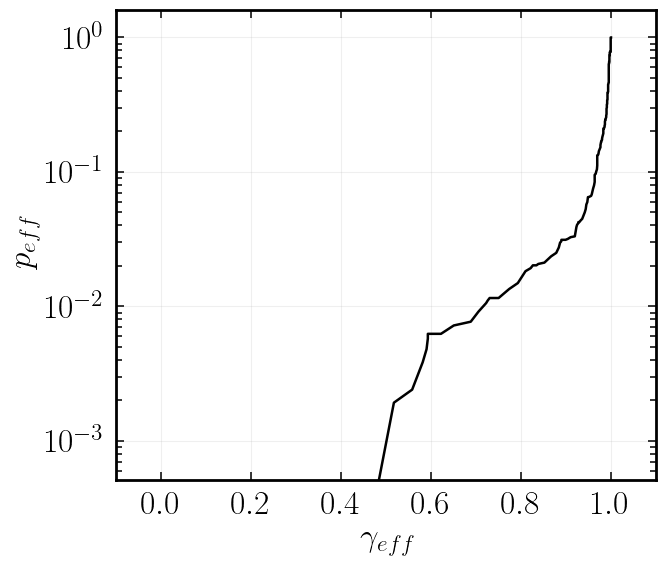

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(tpr_test, fpr_test, color="black", linewidth=1.8, label = f"p\nentries = {len(protons_test)} \n" f"$\\gamma$\nentries = {len(gammas_test)}")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=6)
ax.minorticks_off()

ax.set_xlabel(r"$\gamma_{eff}$", fontsize=24)
ax.set_ylabel(r"$p_{eff}$", fontsize=24)


ax.set_yscale("log")
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0.51e-3, 1.6)

ax.grid(True, alpha=0.2)
plt.xticks([0, 0.20, 0.40, 0.60, 0.80, 1])

handles = [
    plt.Line2D([0], [0], color="black", linewidth=1.8),
]

plt.tight_layout()

plt.savefig(pictures_save_dir / "test_peff_vs_geff_gamma_proton.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "test_peff_vs_geff_gamma_proton.png", dpi=600, bbox_inches="tight")

plt.show()

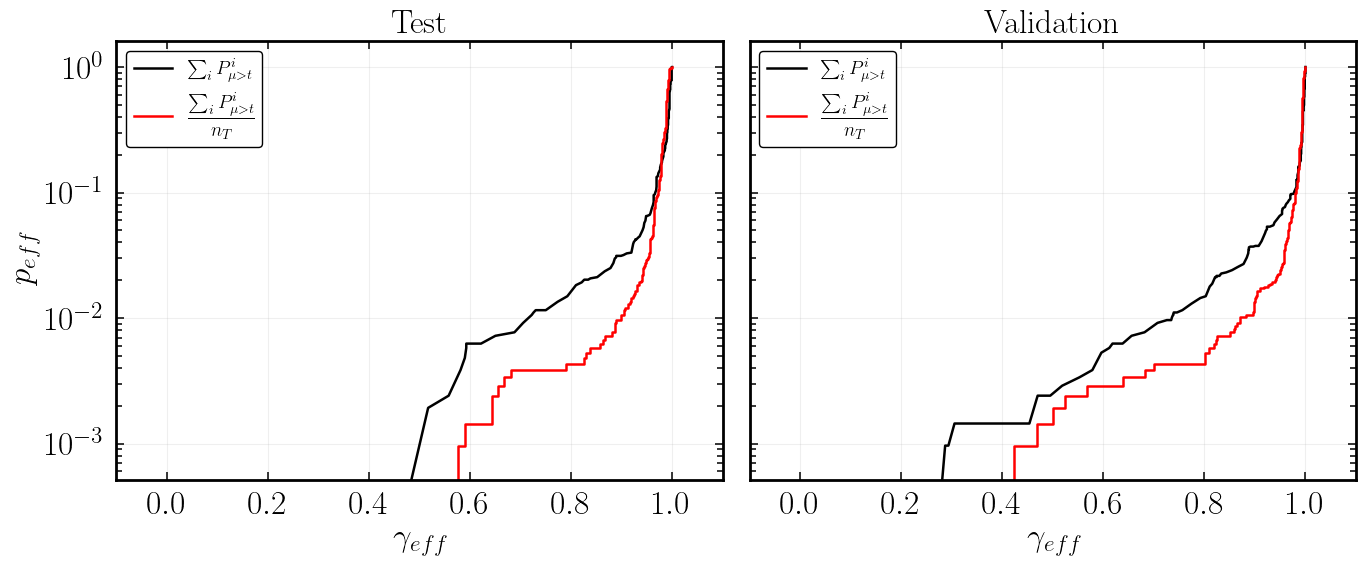

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].plot(tpr_test, fpr_test, color="black", linewidth=1.8, label = r"$\sum_{i}{P_{\mu>t}^{i}}$")
axes[0].plot(mean_tpr_test, mean_fpr_test, color="red", linewidth=1.8, label = r"$\dfrac{\sum_{i}{P_{\mu>t}^{i}}}{n_{T}}$")
axes[0].set_title("Test", fontsize=24)

axes[1].plot(tpr_val, fpr_val, color="black", linewidth=1.8, label = r"$\sum_{i}{P_{\mu>t}^{i}}$")
axes[1].plot(mean_tpr_val, mean_fpr_val, color="red", linewidth=1.8, label = r"$\dfrac{\sum_{i}{P_{\mu>t}^{i}}}{n_{T}}$")
axes[1].set_title("Validation", fontsize=24)

for ax in axes:

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=24, length=6)
    ax.minorticks_off()

    ax.set_xlabel(r"$\gamma_{eff}$", fontsize=24)

    ax.set_yscale("log")
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0.51e-3, 1.6)

    ax.grid(True, alpha=0.2)
    ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1])

    ax.legend(fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left")

axes[0].set_ylabel(r"$p_{eff}$", fontsize=24)

plt.tight_layout()

plt.savefig(pictures_save_dir / "test_val_sum_vs_mean_sum_peff_vs_geff.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "test_val_sum_vs_mean_sum_peff_vs_geff.png", dpi=600, bbox_inches="tight")

plt.show()

In [22]:
signal_to_background = gh.get_S_to_B_ratio(gammas = gammas_test, protons = protons_test)

S_list = np.asarray(signal_to_background.S_list, dtype = float)
S_to_sqrtB_list = np.asarray(signal_to_background.S_to_sqrtB_list, dtype = float)

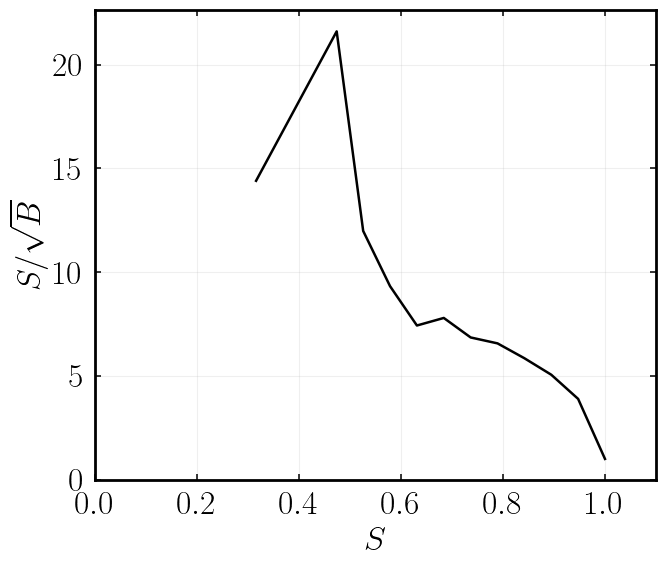

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(S_list, S_to_sqrtB_list, color="black", linewidth=1.8)

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=4)
ax.minorticks_off()

ax.set_xlabel(r"$S$", fontsize=24)
ax.set_ylabel(r"$S/\sqrt{B}$", fontsize=24)

ax.set_xlim(0, 1.1)

ax.grid(True, alpha=0.2)

ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1.0])

plt.tight_layout()

plt.savefig(pictures_save_dir / "SNR_gamma_proton.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "SNR_gamma_proton.png", dpi=600, bbox_inches="tight")

plt.show()

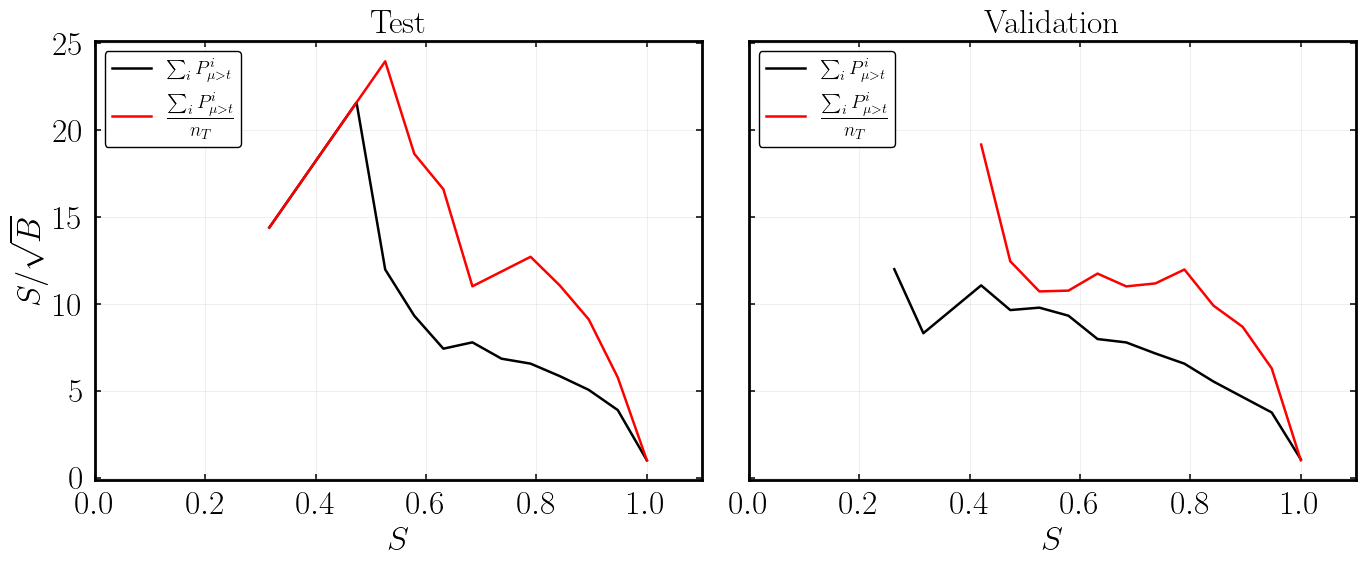

In [24]:
signal_to_background = gh.get_S_to_B_ratio(gammas = gammas_test, protons = protons_test)
mean_signal_to_background = gh.get_S_to_B_ratio(gammas = mean_gammas_test, protons = mean_protons_test)

signal_to_background_val = gh.get_S_to_B_ratio(gammas = gammas_val, protons = protons_val)
mean_signal_to_background_val = gh.get_S_to_B_ratio(gammas = mean_gammas_val, protons = mean_protons_val)

S_list = np.asarray(signal_to_background.S_list, dtype = float)
S_to_sqrtB_list = np.asarray(signal_to_background.S_to_sqrtB_list, dtype = float)

mean_S_list = np.asarray(mean_signal_to_background.S_list, dtype = float)
mean_S_to_sqrtB_list = np.asarray(mean_signal_to_background.S_to_sqrtB_list, dtype = float)

S_list_val = np.asarray(signal_to_background_val.S_list, dtype = float)
S_to_sqrtB_list_val = np.asarray(signal_to_background_val.S_to_sqrtB_list, dtype = float)

mean_S_list_val = np.asarray(mean_signal_to_background_val.S_list, dtype = float)
mean_S_to_sqrtB_list_val = np.asarray(mean_signal_to_background_val.S_to_sqrtB_list, dtype = float)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].plot(S_list, S_to_sqrtB_list, color="black", linewidth=1.8, label = r"$\sum_{i}{P_{\mu>t}^{i}}$")
axes[0].plot(mean_S_list, mean_S_to_sqrtB_list, color="red", linewidth=1.8, label = r"$\dfrac{\sum_{i}{P_{\mu>t}^{i}}}{n_{T}}$")
axes[0].set_title("Test", fontsize=24)

axes[1].plot(S_list_val, S_to_sqrtB_list_val, color="black", linewidth=1.8, label = r"$\sum_{i}{P_{\mu>t}^{i}}$")
axes[1].plot(mean_S_list_val, mean_S_to_sqrtB_list_val, color="red", linewidth=1.8, label = r"$\dfrac{\sum_{i}{P_{\mu>t}^{i}}}{n_{T}}$")
axes[1].set_title("Validation", fontsize=24)

for ax in axes:

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=24, length=4)
    ax.minorticks_off()

    ax.set_xlabel(r"$S$", fontsize=24)
    ax.set_xlim(0, 1.1)

    ax.grid(True, alpha=0.2)
    ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1.0])

    ax.legend(fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left")

axes[0].set_ylabel(r"$S/\sqrt{B}$", fontsize=24)

plt.tight_layout()

plt.savefig(pictures_save_dir / "test_val_sum_vs_mean_sum_SNR.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "test_val_sum_vs_mean_sum_SNR.png", dpi=600, bbox_inches="tight")

plt.show()

In [25]:
muon_probability_data = gh.get_probabilities_and_nmu(
                                                    protons_test = protons_testing,
                                                    best_threshold_val = best_threshold_val,
                                                    bin_width = 5,
                                                    min_bin_entries = 20)

n_muons = muon_probability_data.n_muons
p_cum = muon_probability_data.p_cum

bin_centers = muon_probability_data.bin_centers
mean_pr = muon_probability_data.mean_pr
err_pr = muon_probability_data.err_pr
p_bin_centers = muon_probability_data.p_bin_centers


fit_results = gh.fit_probabilities_vs_nmu(
    bin_centers=bin_centers,
    mean_pr=mean_pr,
    err_pr=err_pr,
    n_muons=n_muons,
    p_cum=p_cum,
    n_fit_min=0,
    n_fit_max=100,
    n_fit_points=300)

n_fit = fit_results.n_fit
p_fit = fit_results.p_fit
chi2_val = fit_results.chi2
ndf = fit_results.ndf
rho = fit_results.rho

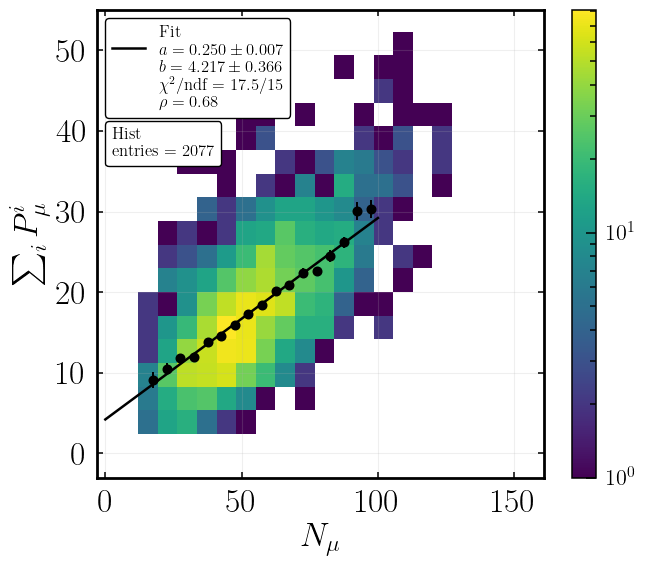

In [26]:
n_max = np.max(n_muons)

fig, ax = plt.subplots(figsize=(7, 6))

h = ax.hist2d(n_muons, p_cum, bins=20, cmap="viridis", norm=colors.LogNorm(vmin=1))

ax.errorbar(bin_centers, mean_pr, yerr=err_pr, fmt="o", color="black", markersize=6, elinewidth=1.4, ecolor="black", markeredgecolor="black", markeredgewidth=1.2)

fit_line, = ax.plot(n_fit, p_fit, color="black", linewidth=1.8)

for spine in ax.spines.values():

    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=4)
ax.minorticks_off()
ax.set_xlabel(r"$N_{\mu}$", fontsize=24)
ax.set_ylabel(r"$\sum_i P_{\mu}^{i}$", fontsize=24)
ax.set_xlim(-3, n_max + 5)
ax.set_ylim(-3, 55)
ax.grid(True, alpha=0.2)

cbar = plt.colorbar(h[3], ax=ax)
cbar.ax.tick_params(labelsize=16)

legend_fit = ax.legend([fit_line], [f"Fit\n$a = {fit_results.slope:.3f} \\pm {fit_results.slope_error:.3f}$\n$b = {fit_results.intercept:.3f} \\pm {fit_results.intercept_error:.3f}$\n$\\chi^2$/ndf = {fit_results.chi2:.1f}/{fit_results.ndf}\n$\\rho = {fit_results.rho:.2f}$"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", handler_map={Line2D: gh.OffsetLineHandler(y_offset=20)})
legend_data = ax.legend([Line2D([], [], linestyle="none")], [f"Hist\nentries = {len(n_muons)}"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", bbox_to_anchor=(0.0, 0.78), handlelength=0, handletextpad=0)

ax.add_artist(legend_fit)

plt.tight_layout()

plt.savefig(pictures_save_dir / "all_probs_vs_all_nmu.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "all_probs_vs_all_nmu.png", dpi=600, bbox_inches="tight")

plt.show()

In [27]:
mean_muon_probability_data = gh.get_mean_probabilities_and_nmu(
    protons_test = protons_testing,
    best_threshold_val = best_threshold_val_mean,
    bin_width = 0.04,
    min_bin_entries = 10)

mean_n_muons = mean_muon_probability_data.n_muons
mean_p_cum = mean_muon_probability_data.p_cum

mean_bin_centers = mean_muon_probability_data.bin_centers
mean_mean_pr = mean_muon_probability_data.mean_pr
mean_err_pr = mean_muon_probability_data.err_pr
mean_p_bin_centers = mean_muon_probability_data.p_bin_centers


mean_fit_results = gh.fit_probabilities_vs_nmu(
    bin_centers=mean_bin_centers,
    mean_pr=mean_mean_pr,
    err_pr=mean_err_pr,
    n_muons=mean_n_muons,
    p_cum=mean_p_cum,
    n_fit_min=0,
    n_fit_max=1,
    n_fit_points=300)

mean_n_fit = mean_fit_results.n_fit
mean_p_fit = mean_fit_results.p_fit
mean_chi2_val = mean_fit_results.chi2
mean_ndf = mean_fit_results.ndf
mean_rho = mean_fit_results.rho

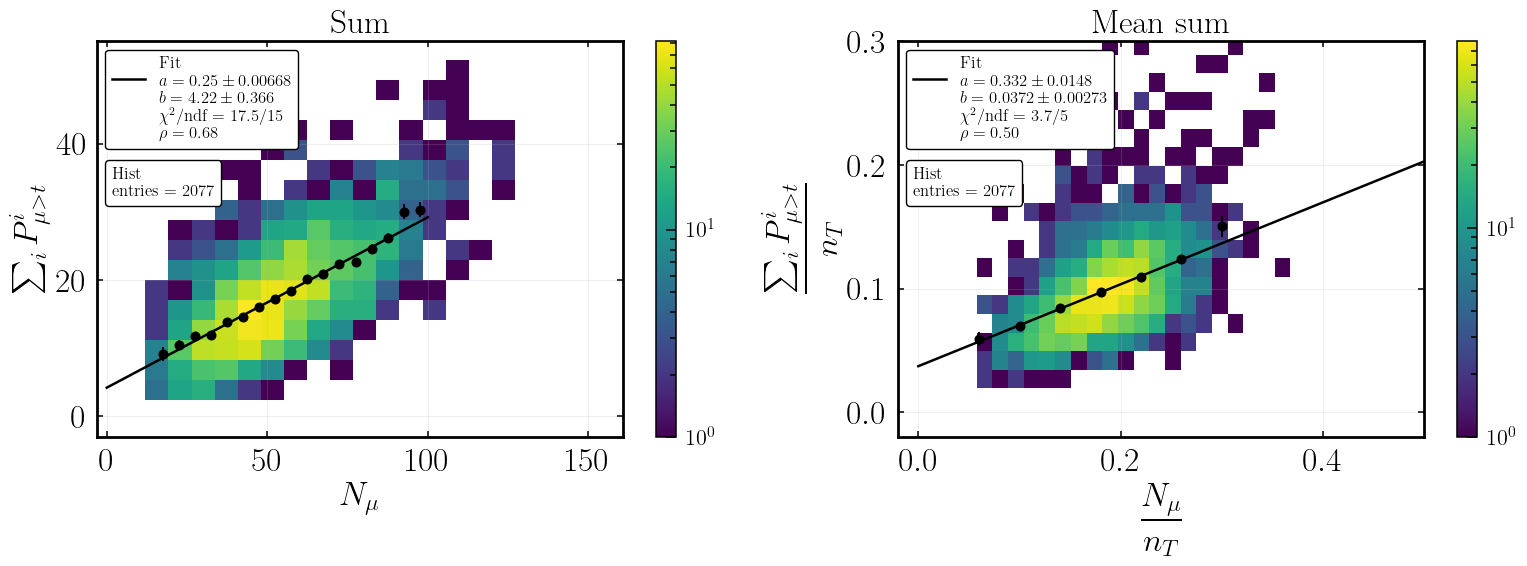

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_muons = np.asarray(muon_probability_data.n_muons, dtype = float)
p_cum = np.asarray(muon_probability_data.p_cum, dtype = float)

mean_n_muons = np.asarray(mean_muon_probability_data.n_muons, dtype = float)
mean_p_cum = np.asarray(mean_muon_probability_data.p_cum, dtype = float)

plot_data = [
    (n_muons, p_cum, bin_centers, mean_pr, err_pr, n_fit, p_fit, fit_results,
     r"$\sum_i P_{\mu>t}^{i}$", "Sum"),
    (mean_n_muons, mean_p_cum, mean_bin_centers, mean_mean_pr, mean_err_pr, mean_n_fit, mean_p_fit, mean_fit_results,
     r"$\dfrac{\sum_i P_{\mu>t}^{i}}{n_T}$", "Mean sum")
]

for ax, (x, y, centers, means, errors, x_fit, y_fit, fit, ylabel, title) in zip(axes, plot_data):

    h = ax.hist2d(x, y, bins=20, cmap="viridis", norm=colors.LogNorm(vmin=1))

    ax.errorbar(centers, means, yerr=errors, fmt="o", color="black", markersize=6, elinewidth=1.4, ecolor="black", markeredgecolor="black", markeredgewidth=1.2)

    fit_line, = ax.plot(x_fit, y_fit, color="black", linewidth=1.8)

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=24, length=4)
    ax.minorticks_off()

    ax.set_title(title, fontsize=24)
    ax.set_ylabel(ylabel, fontsize=24)
    ax.set_xlim(-3, np.max(x) + 5)
    ax.grid(True, alpha=0.2)

    cbar = fig.colorbar(h[3], ax=ax)
    cbar.ax.tick_params(labelsize=16)

    legend_fit = ax.legend([fit_line], [f"Fit\n$a = {fit.slope:.3g} \\pm {fit.slope_error:.3g}$\n$b = {fit.intercept:.3g} \\pm {fit.intercept_error:.3g}$\n$\\chi^2$/ndf = {fit.chi2:.1f}/{fit.ndf}\n$\\rho = {fit.rho:.2f}$"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", handler_map={Line2D: gh.OffsetLineHandler(y_offset=20)})

    legend_data = ax.legend([Line2D([], [], linestyle="none")], [f"Hist\nentries = {len(x)}"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", bbox_to_anchor=(0.0, 0.72), handlelength=0, handletextpad=0)

    ax.add_artist(legend_fit)

axes[0].set_ylim(-3, 55)
axes[1].set_ylim(-0.02, 0.3)
axes[1].set_xlim(-0.02, 0.5)
axes[0].set_xlabel(r"$N_{\mu}$", fontsize=24)
axes[1].set_xlabel(r"$\dfrac{N_{\mu}}{n_{T}}$", fontsize=24)


plt.tight_layout()

plt.savefig(pictures_save_dir / "sum_vs_mean_sum_probs_vs_nmu.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "sum_vs_mean_sum_probs_vs_nmu.png", dpi=600, bbox_inches="tight")

plt.show()

In [29]:
estimator_results = gh.get_estimator_results(bin_centers=bin_centers, p_bin_centers=p_bin_centers, slope=fit_results.slope, intercept=fit_results.intercept)

est_list = estimator_results.est_list
resolution = estimator_results.resolution
bias = estimator_results.bias
bias_err = estimator_results.bias_error

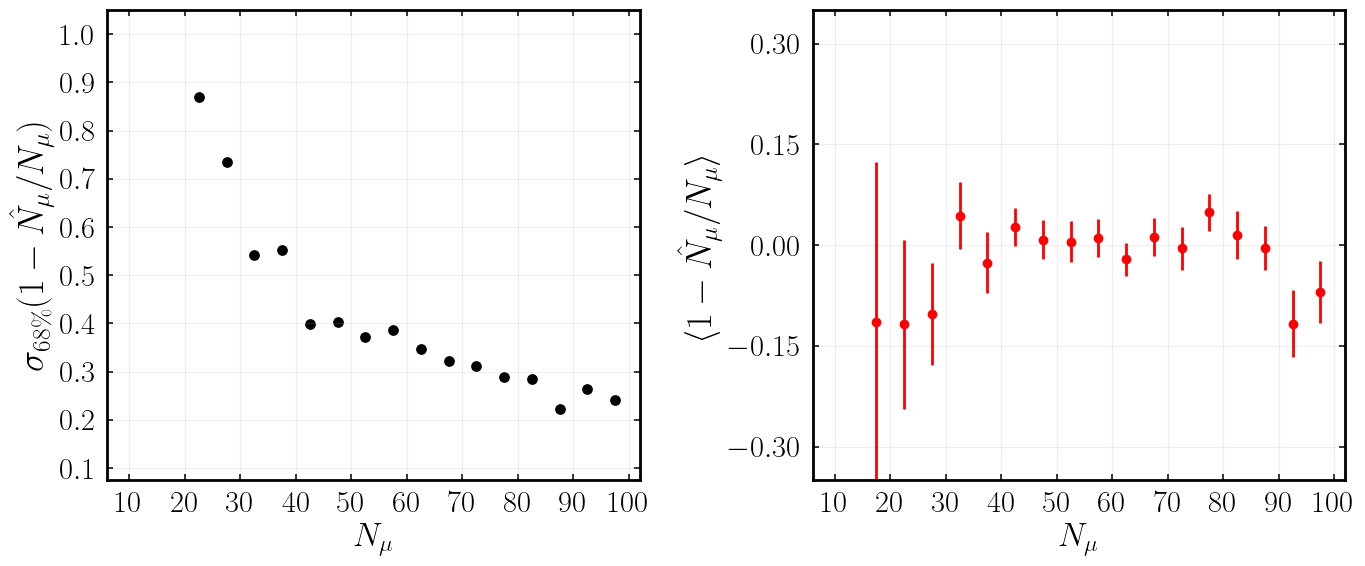

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(bin_centers, resolution, color="black", s=45, edgecolors="black", linewidths=1.0)
ax[1].errorbar(bin_centers, bias, yerr = bias_err, fmt="o", color="red", markersize=6, ecolor="red", markeredgecolor="red", markeredgewidth=1.0)

for i in range(2):
    for spine in ax[i].spines.values():
        spine.set_linewidth(2)
    ax[i].tick_params(axis="both", which="major", labelsize=22, length=4)
    ax[i].minorticks_off()
    ax[i].grid(True, alpha=0.2)
    ax[i].set_xlim(np.min(bin_centers) - 5, np.max(bin_centers) + 5)
    ax[i].set_xlabel(r"$N_{\mu}$", fontsize=24)

ax[0].set_ylabel(r" $\sigma_{68 \%} (1 - \hat{N_{\mu}}/N_{\mu})$", fontsize=26)
ax[1].set_ylabel(r"$\langle 1 - \hat{N}_{\mu}/N_{\mu} \rangle$", fontsize=26)

ax[0].set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax[1].set_xticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

ax[0].set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax[1].set_yticks([-0.3, -0.15, 0, 0.15, 0.3])

ax[0].set_ylim(0.075, 1.05)
ax[1].set_ylim(-0.35, 0.35)
ax[0].set_xlim(6, 102)
ax[1].set_xlim(6, 102)

plt.tight_layout()

plt.savefig(pictures_save_dir / "all_probs_muon_bias_res.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "all_probs_muon_bias_res.png", dpi=600, bbox_inches="tight")

plt.show()

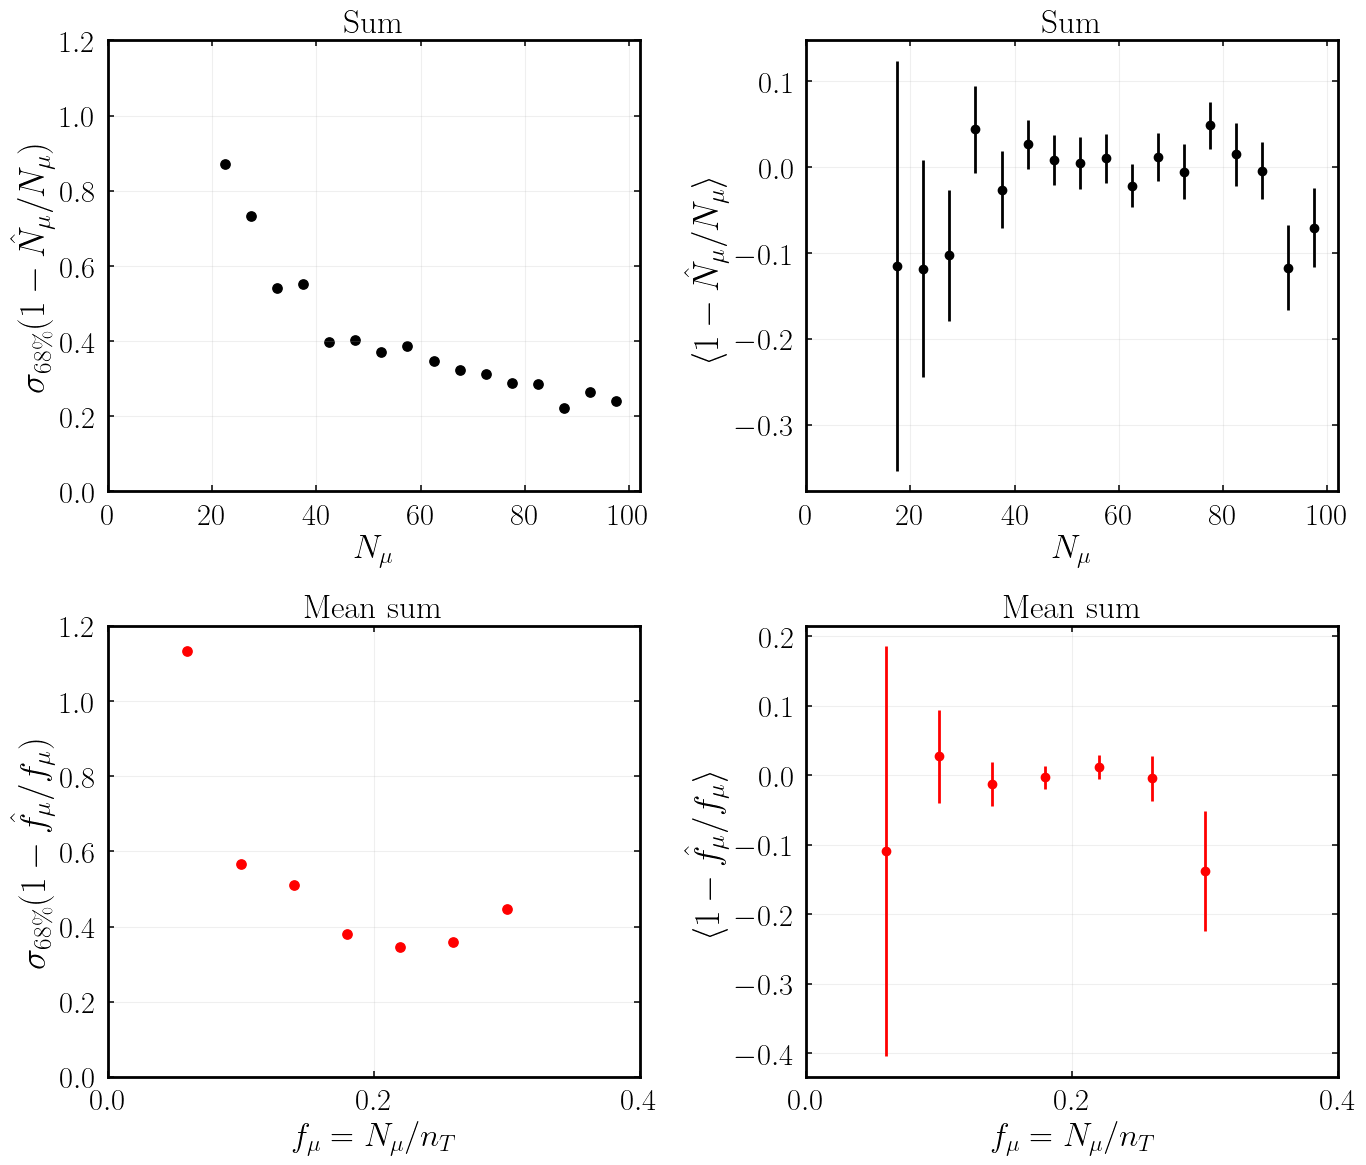

In [31]:
estimator_results = gh.get_estimator_results(bin_centers=bin_centers, p_bin_centers=p_bin_centers, slope=fit_results.slope, intercept=fit_results.intercept)

est_list = estimator_results.est_list
resolution = estimator_results.resolution
bias = estimator_results.bias
bias_err = estimator_results.bias_error

mean_estimator_results = gh.get_estimator_results(bin_centers=mean_bin_centers, p_bin_centers=mean_p_bin_centers, slope=mean_fit_results.slope, intercept=mean_fit_results.intercept)

mean_est_list = mean_estimator_results.est_list
mean_resolution = mean_estimator_results.resolution
mean_bias = mean_estimator_results.bias
mean_bias_err = mean_estimator_results.bias_error

fig, ax = plt.subplots(2, 2, figsize=(14, 12))

ax[0, 0].scatter(bin_centers, resolution, color="black", s=45, edgecolors="black", linewidths=1.0)
ax[0, 1].errorbar(bin_centers, bias, yerr = bias_err, fmt="o", color="black", markersize=6, ecolor="black", markeredgecolor="black", markeredgewidth=1.0)

ax[1, 0].scatter(mean_bin_centers, mean_resolution, color="red", s=45, edgecolors="red", linewidths=1.0)
ax[1, 1].errorbar(mean_bin_centers, mean_bias, yerr = mean_bias_err, fmt="o", color="red", markersize=6, ecolor="red", markeredgecolor="red", markeredgewidth=1.0)

for a in ax.flat:

    for spine in a.spines.values():
        spine.set_linewidth(2)

    a.tick_params(axis="both", which="major", labelsize=22, length=4)
    a.minorticks_off()
    a.grid(True, alpha=0.2)

for i in range(2):

    ax[0, i].set_title("Sum", fontsize=24)
    ax[0, i].set_xlabel(r"$N_{\mu}$", fontsize=24)
    ax[0, i].set_xticks([0, 20, 40, 60, 80, 100])
    ax[0, i].set_xlim(0, 102)
    

    ax[1, i].set_title("Mean sum", fontsize=24)
    ax[1, i].set_xlabel(r"$f_{\mu} = N_{\mu}/n_T$", fontsize=24)
    ax[1, i].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    ax[1, i].set_xlim(0, 0.4)
    
    

ax[1, 0].set_ylim(0, 1.2)
ax[0, 0].set_ylim(0, 1.2)
ax[0, 0].set_ylabel(r"$\sigma_{68\%}(1 - \hat{N}_{\mu}/N_{\mu})$", fontsize=26)
ax[0, 1].set_ylabel(r"$\langle 1 - \hat{N}_{\mu}/N_{\mu} \rangle$", fontsize=26)

ax[1, 0].set_ylabel(r"$\sigma_{68\%}(1 - \hat{f}_{\mu}/f_{\mu})$", fontsize=26)
ax[1, 1].set_ylabel(r"$\langle 1 - \hat{f}_{\mu}/f_{\mu} \rangle$", fontsize=26)

plt.tight_layout()

plt.savefig(pictures_save_dir / "sum_vs_mean_sum_muon_bias_res.pdf", dpi=600, bbox_inches="tight")
plt.savefig(pictures_save_dir / "sum_vs_mean_sum_muon_bias_res.png", dpi=600, bbox_inches="tight")

plt.show()

Mean number of muons =  53.877226769378915


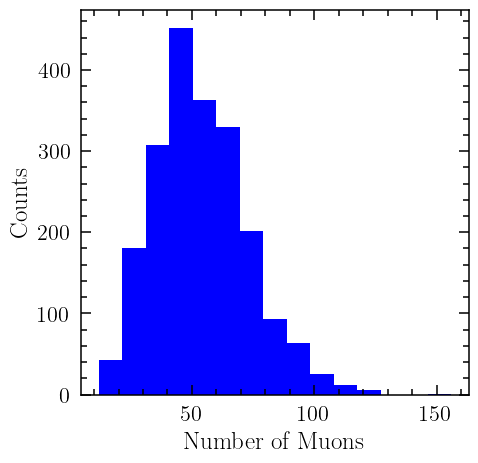

In [32]:
plt.hist(n_muons, color = "blue", histtype = "stepfilled", bins = 15)
print("Mean number of muons = ", np.mean(n_muons))
plt.xlabel("Number of Muons")
plt.ylabel("Counts")
plt.show()

In [33]:
muon_residual_results = gh.get_muon_residual_results(protons_test=protons_testing, best_threshold=best_threshold_val, slope=fit_results.slope, intercept=fit_results.intercept)
delta_n = muon_residual_results.delta_n
bias = muon_residual_results.bias
p16 = muon_residual_results.p16
p84 = muon_residual_results.p84
width_68 = muon_residual_results.width_68

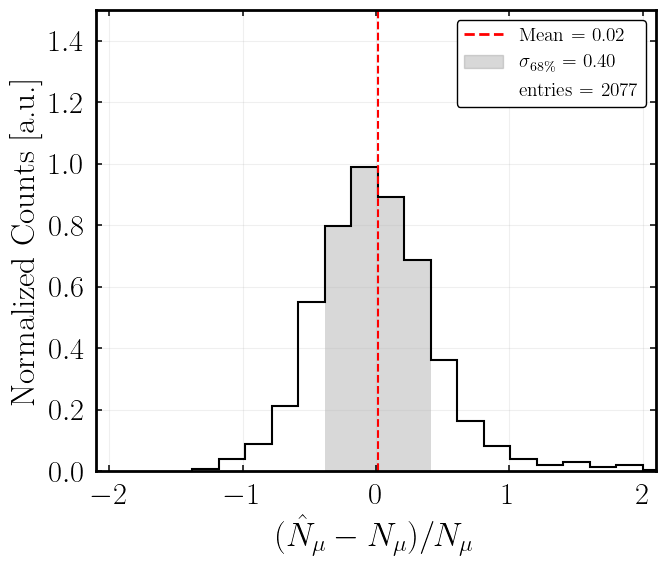

Delta N statistics:
Bias (mean) = 0.02
68% half width = 0.40


In [34]:
fig, ax = plt.subplots(figsize=(7, 6))

counts, bins, _ = ax.hist(delta_n, bins=25, histtype="step", color="black", linewidth=1.5, density = True)

centers = 0.5 * (bins[:-1] + bins[1:])
mask = (centers >= p16) & (centers <= p84)

ax.bar(centers[mask], counts[mask], width=np.diff(bins)[mask], align="center", color="gray", alpha=0.3, edgecolor="none")
ax.axvline(bias, linestyle="--", linewidth = 1.5, color="red")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=22, length=4)
ax.minorticks_off()

ax.set_xlabel(r"$(\hat{N}_{\mu} - N_{\mu})/N_{\mu}$", fontsize=24)
ax.set_ylabel("Normalized Counts [a.u.]", fontsize=24)

ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2])


ax.set_xlim(-2.1, 2.1)
ax.set_ylim(0, 1.5)

ax.grid(True, alpha=0.2)

handles = [
    plt.Line2D([0], [0], color="red", linestyle="--", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.3),
    plt.Line2D([], [], linestyle="none")
]

labels = [
    f"Mean = {bias:.2f}",
    r"$\sigma_{68\%}$ = " f"{width_68:.2f}",
    f"entries = {len(delta_n)}"
]

ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0)
plt.tight_layout()

plt.savefig(pictures_save_dir / "all_probs_muon_res_dist.pdf", dpi = 600, bbox_inches = "tight")
plt.savefig(pictures_save_dir / "all_probs_muon_res_dist.png", dpi = 600, bbox_inches = "tight")

plt.show()

print("Delta N statistics:")
print(f"Bias (mean) = {bias:.2f}")
print(f"68% half width = {width_68:.2f}")

Sum:
Bias (mean) = 0.02
68% half width = 0.40
Mean sum:
Bias (mean) = 0.00
68% half width = 0.40


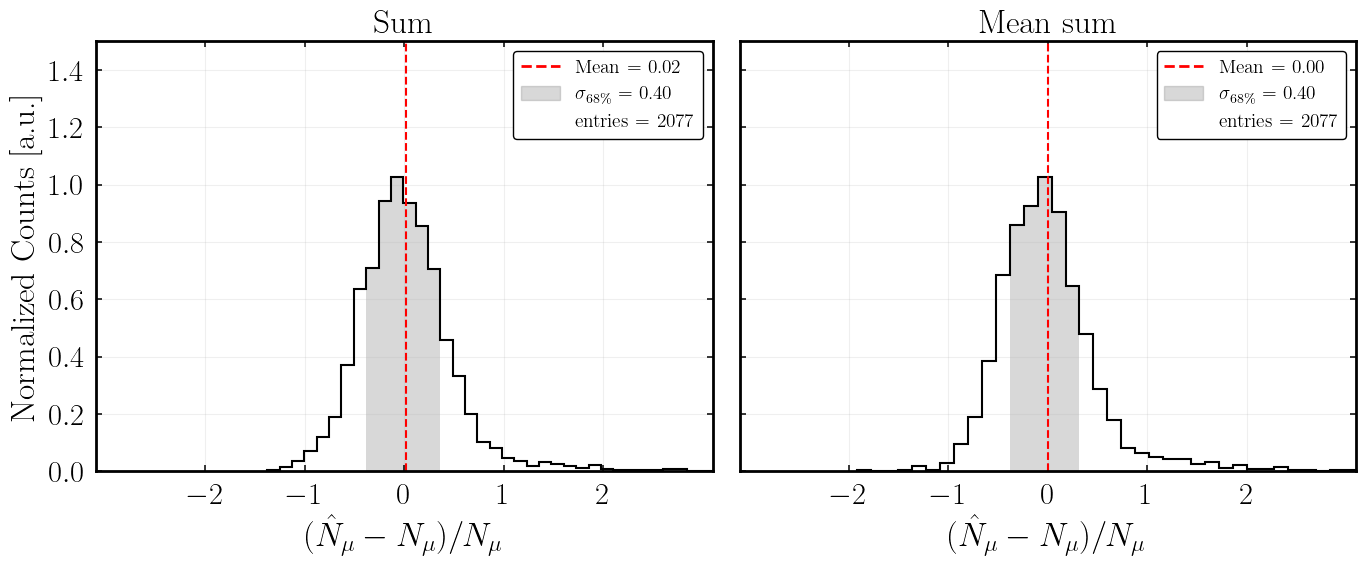

In [35]:
muon_residual_results = gh.get_muon_residual_results(protons_test=protons_testing, best_threshold=best_threshold_val, slope=fit_results.slope, intercept=fit_results.intercept)

mean_muon_residual_results = gh.get_mean_muon_residual_results(
    protons_test=protons_testing,
    best_threshold=best_threshold_val_mean,
    slope=mean_fit_results.slope,
    intercept=mean_fit_results.intercept)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)


plot_data = [
    (muon_residual_results, "Sum"),
    (mean_muon_residual_results, "Mean sum")
]

for ax, (residual_results, title) in zip(axes, plot_data):

    counts, bins, _ = ax.hist(residual_results.delta_n, bins=40, histtype="step", color="black", linewidth=1.5, density = True)

    centers = 0.5 * (bins[:-1] + bins[1:])
    mask = (centers >= residual_results.p16) & (centers <= residual_results.p84)

    ax.bar(centers[mask], counts[mask], width=np.diff(bins)[mask], align="center", color="gray", alpha=0.3, edgecolor="none")
    ax.axvline(residual_results.bias, linestyle="--", linewidth = 1.5, color="red")

    for spine in ax.spines.values():
        spine.set_linewidth(2)

    ax.tick_params(axis="both", which="major", labelsize=22, length=4)
    ax.minorticks_off()

    ax.set_title(title, fontsize=24)
    ax.set_xlabel(r"$(\hat{N}_{\mu} - N_{\mu})/N_{\mu}$", fontsize=24)

    ax.set_xticks([-2, -1, 0, 1, 2])
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4])

    ax.set_xlim(-3.1, 3.1)
    ax.set_ylim(0, 1.5)

    ax.grid(True, alpha=0.2)

    handles = [
        plt.Line2D([0], [0], color="red", linestyle="--", linewidth=2),
        plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.3),
        plt.Line2D([], [], linestyle="none")
    ]

    labels = [
        f"Mean = {residual_results.bias:.2f}",
        r"$\sigma_{68\%}$ = " f"{residual_results.width_68:.2f}",
        f"entries = {len(residual_results.delta_n)}"
    ]

    ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0)

    print(f"{title}:")
    print(f"Bias (mean) = {residual_results.bias:.2f}")
    print(f"68% half width = {residual_results.width_68:.2f}")

axes[0].set_ylabel("Normalized Counts [a.u.]", fontsize=24)

plt.tight_layout()

plt.savefig(pictures_save_dir / "sum_vs_mean_sum_muon_res_dist.pdf", dpi = 600, bbox_inches = "tight")
plt.savefig(pictures_save_dir / "sum_vs_mean_sum_muon_res_dist.png", dpi = 600, bbox_inches = "tight")

plt.show()